In [4]:
#VISUALISASI DATA
#import library & load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set tema global Seaborn
sns.set_theme(style='whitegrid', palette='Set2')

# Load dataset
df = sns.load_dataset('tips')
print('Shape dataset:', df.shape)
print('\nInfo kolom:')
print(df.dtypes)
print('\nStatistik deskriptif:')
df.describe().round(2)

Shape dataset: (244, 7)

Info kolom:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Statistik deskriptif:


,total_bill,tip,size
count,244.00,244.00,244.00
mean,19.79,3.00,2.57
std,8.90,1.38,0.95
min,3.07,1.00,1.00
25%,13.35,2.00,2.00
50%,17.80,2.90,2.00
75%,24.13,3.56,3.00
max,50.81,10.00,6.00


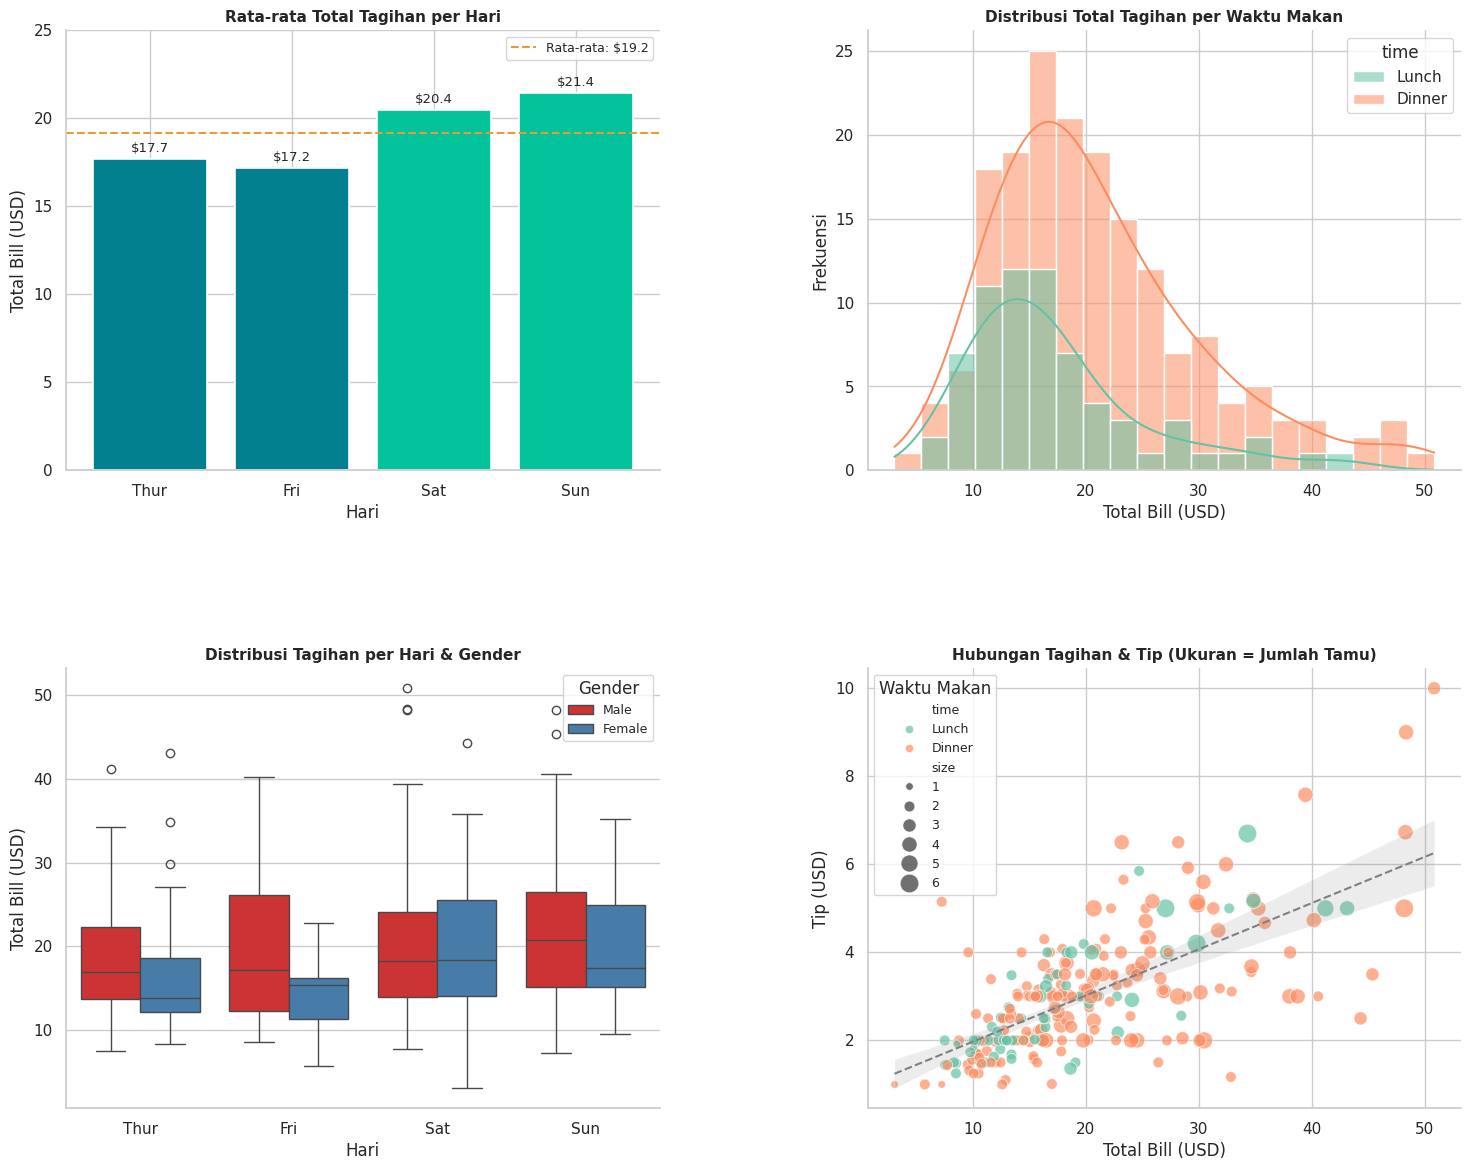

Dashboard tersimpan sebagai dashboard_tips.png


In [5]:
#DASHBOARD
# ── SETUP FIGURE ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])   # kiri atas
ax2 = fig.add_subplot(gs[0, 1])   # kanan atas
ax3 = fig.add_subplot(gs[1, 0])   # kiri bawah
ax4 = fig.add_subplot(gs[1, 1])   # kanan bawah

# ── GRAFIK 1: Bar Chart — Rata-rata Tagihan per Hari ──────────────────
avg_by_day = df.groupby('day')['total_bill'].mean().reindex(['Thur', 'Fri', 'Sat', 'Sun'])
colors_bar = ['#028090' if v < avg_by_day.mean() else '#02C39A' for v in avg_by_day]
bars = ax1.bar(avg_by_day.index, avg_by_day.values, color=colors_bar, edgecolor='white', linewidth=1.2)
ax1.axhline(avg_by_day.mean(), color='#E69B3A', linestyle='--', linewidth=1.5,
            label=f'Rata-rata: ${avg_by_day.mean():.1f}')
ax1.bar_label(bars, fmt='$%.1f', padding=3, fontsize=9.5)
ax1.set_title('Rata-rata Total Tagihan per Hari', fontsize=11, fontweight='bold')
ax1.set_xlabel('Hari')
ax1.set_ylabel('Total Bill (USD)')
ax1.set_ylim(0, 25)
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

# ── GRAFIK 2: Histogram + KDE — Distribusi Tagihan per Waktu Makan ───
sns.histplot(data=df, x='total_bill', hue='time',
             kde=True, palette='Set2', alpha=0.55, bins=20, ax=ax2)
ax2.set_title('Distribusi Total Tagihan per Waktu Makan', fontsize=11, fontweight='bold')
ax2.set_xlabel('Total Bill (USD)')
ax2.set_ylabel('Frekuensi')
ax2.spines[['top', 'right']].set_visible(False)

# ── GRAFIK 3: Boxplot — Distribusi Tagihan per Hari & Gender ─────────
sns.boxplot(data=df, x='day', y='total_bill', hue='sex',
            palette='Set1', order=['Thur', 'Fri', 'Sat', 'Sun'], ax=ax3)
ax3.set_title('Distribusi Tagihan per Hari & Gender', fontsize=11, fontweight='bold')
ax3.set_xlabel('Hari')
ax3.set_ylabel('Total Bill (USD)')
ax3.legend(title='Gender', fontsize=9)
ax3.spines[['top', 'right']].set_visible(False)

# ── GRAFIK 4: Scatter Plot — Hubungan Tagihan & Tip ──────────────────
sns.scatterplot(data=df, x='total_bill', y='tip',
                hue='time', size='size', sizes=(30, 180),
                palette='Set2', alpha=0.7, ax=ax4)
sns.regplot(data=df, x='total_bill', y='tip',
            scatter=False, color='gray',
            line_kws={'linestyle': '--', 'linewidth': 1.5}, ax=ax4)
ax4.set_title('Hubungan Tagihan & Tip (Ukuran = Jumlah Tamu)', fontsize=11, fontweight='bold')
ax4.set_xlabel('Total Bill (USD)')
ax4.set_ylabel('Tip (USD)')
ax4.legend(title='Waktu Makan', fontsize=9)
ax4.spines[['top', 'right']].set_visible(False)

# ── EKSPOR ─────────────────────────────────────────────────────────────
plt.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard_tips.png')

## Analisis Dashboard



---



### Grafik 1 - Bar Chart: Rata-rata Total Tagihan per Hari

**What?**  
Grafik bar chart ini menampilkan rata-rata total tagihan (USD) di sebuah restoran berdasarkan hari dalam seminggu (Kamis–Minggu) dari dataset Tips yang terdiri dari 244 observasi. Rata-rata tagihan tertinggi terjadi pada hari Minggu ($21.4) dan Sabtu ($20.4), sedangkan terendah pada Kamis ($17.7) dan Jumat ($17.2). Garis oranye putus-putus menunjukkan rata-rata keseluruhan sebesar $19.8.

**So What?**  
Hari akhir pekan (Sabtu dan Minggu) menghasilkan rata-rata tagihan yang nyata lebih tinggi dibanding hari kerja. Selisihnya mencapai sekitar $4.2 atau ~24% lebih tinggi dari hari Jumat. Hal ini mengindikasikan bahwa pelanggan akhir pekan cenderung makan dalam kelompok lebih besar atau memesan menu yang lebih mahal, kemungkinan karena momen makan keluarga atau acara sosial.

**Now What?**  
Manajemen restoran sebaiknya mengalokasikan staf lebih banyak dan memastikan stok bahan baku yang cukup di akhir pekan untuk mengoptimalkan pelayanan. Perlu juga dieksplorasi apakah pola ini konsisten sepanjang tahun atau hanya terjadi di musim tertentu, serta apakah ada korelasi antara hari dengan jumlah tamu per meja.



---



### Grafik 2 — Histogram + KDE: Distribusi Tagihan per Waktu Makan

**What?**  
Grafik histogram dengan kurva KDE ini menampilkan distribusi total tagihan (USD) untuk dua waktu makan: Lunch dan Dinner. Distribusi keduanya miring ke kanan (right-skewed), dengan sebagian besar tagihan berada di kisaran $10–$25. Distribusi Dinner lebih lebar dan memiliki ekor yang lebih panjang, dengan beberapa tagihan mencapai lebih dari $50.

**So What?**  
Waktu makan Dinner secara konsisten menghasilkan tagihan yang lebih tinggi dan variasinya lebih besar dibandingkan Lunch. Ini menunjukkan bahwa pelanggan makan malam lebih heterogen, mulai dari yang pesan sedikit hingga kelompok besar dengan tagihan tinggi. Pola right-skewed ini mengindikasikan adanya pelanggan dengan tagihan sangat tinggi (outlier) terutama di sesi Dinner yang menarik rata-rata ke atas.

**Now What?**  
Restoran dapat mempertimbangkan strategi harga berbeda untuk Lunch (paket hemat, combo) dan Dinner (menu premium, paket keluarga). Analisis lanjutan perlu dilakukan untuk mengetahui apakah pelanggan dengan tagihan tinggi di Dinner berasal dari hari tertentu, sehingga promosi dapat ditargetkan secara lebih efektif.



---



## Grafik 3 — Boxplot: Distribusi Tagihan per Hari & Gender

**What?**  
Boxplot ini menampilkan distribusi total tagihan (USD) yang dipecah berdasarkan hari (Kamis–Minggu) dan gender (Male/Female). Setiap kotak merepresentasikan rentang interkuartil (Q1–Q3), garis tengah menunjukkan median, dan titik-titik di luar garis menunjukkan outlier. Terdapat beberapa outlier yang signifikan, terutama pada hari Sabtu dan Minggu.

**So What?**  
Pelanggan laki-laki secara konsisten memiliki median tagihan yang lebih tinggi dan variasi yang lebih besar dibandingkan perempuan di semua hari. Outlier paling banyak terjadi pada hari Sabtu oleh pelanggan laki-laki, dengan satu tagihan mencapai lebih dari $50. Hal ini mengindikasikan bahwa kelompok besar atau pemesanan mewah lebih sering dilakukan oleh pelanggan laki-laki pada akhir pekan.

**Now What?**  
Perlu dianalisis lebih lanjut apakah perbedaan gender ini berkorelasi dengan jumlah tamu per meja (kolom `size`) atau dengan pemilihan menu tertentu. Restoran juga dapat mempertimbangkan program loyalitas yang lebih inklusif agar pelanggan perempuan terdorong untuk memesan lebih banyak pada hari akhir pekan.




---


## Grafik 4 — Scatter Plot: Hubungan Tagihan & Tip

**What?**  
Scatter plot ini menampilkan hubungan antara total tagihan (sumbu X, USD) dan jumlah tip (sumbu Y, USD) dari 244 observasi, dibedakan berdasarkan waktu makan (Lunch/Dinner) dan ukuran titik merepresentasikan jumlah tamu. Garis regresi abu-abu menunjukkan tren umum hubungan kedua variabel.

**So What?**  
Terdapat korelasi positif yang jelas antara total tagihan dan tip: semakin besar tagihan, semakin besar pula tip yang diberikan. Titik-titik berukuran besar (kelompok tamu banyak) cenderung berada di area tagihan tinggi, menunjukkan meja dengan lebih banyak tamu menghasilkan pendapatan dan tip yang lebih besar. Beberapa pelanggan Dinner memberikan tip yang relatif rendah meskipun tagihan cukup tinggi (titik di bawah garis regresi), yang bisa mengindikasikan ketidakpuasan layanan atau kebiasaan tipping yang berbeda.

**Now What?**  
Restoran dapat memotivasi staf untuk memberikan layanan ekstra kepada meja dengan tagihan besar, karena potensi tip-nya lebih tinggi. Perlu juga diperiksa observasi yang tip-nya jauh di bawah garis regresi — apakah ada pola waktu atau hari tertentu yang berkorelasi dengan tip rendah, sebagai bahan evaluasi kualitas layanan.

---
## Kesimpulan Umum

Dari keempat grafik yang telah dibuat dan dianalisis menggunakan pendekatan **What? So what? Now what?**, beberapa temuan utama dari dataset Tips adalah:

1. **Akhir pekan dominan**: Tagihan rata-rata Sabtu-Minggu ~24% lebih tinggi dari hari kerja, dengan variasi yang lebih besar.
2. **Dinner > Lunch**: Distribusi tagihan makan malam lebih lebar dengan ekor kanan lebih panjang, menandakan lebih banyak kelompok besar atau pemesanan premium.
3. **Gender & hari berkorelasi**: Pelanggan laki-laki cenderung tagihan lebih tinggi, terutama di Sabtu-Minggu.
4. **Korelasi positif tagihan–tip**: Hubungan yang kuat menunjukkan kualitas pengalaman makan mendorong pemberian tip lebih besar.
